The key difference:

Linear Regression → keeps all features
Ridge Regression → shrinks coefficients
Lasso Regression → can make coefficients exactly 0 (feature selection)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# ====================================
# Generate Rat Dataset
# ====================================

np.random.seed(42)

n = 200

weight = np.random.normal(300, 40, n)
waist = weight * 0.06 + np.random.normal(0, 1, n)

# Noise features
tail_length = np.random.normal(12, 2, n)
ear_length = np.random.normal(4, 0.5, n)

# Target depends ONLY on weight and waist
obesity_score = (
    0.08 * weight +
    1.20 * waist +
    np.random.normal(0, 3, n)
)

df = pd.DataFrame({
    "weight": weight,
    "waist": waist,
    "tail_length": tail_length,
    "ear_length": ear_length,
    "obesity_score": obesity_score
})

In [3]:
# ====================================
# Train/Test Split
# ====================================

X = df.drop("obesity_score", axis=1)
y = df["obesity_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [4]:
# ====================================
# Models
# ====================================

linear = LinearRegression()
ridge = Ridge(alpha=10)
lasso = Lasso(alpha=0.5)

linear.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [5]:
# ====================================
# Scores
# ====================================

print("Linear R²:",
      round(r2_score(y_test,
                     linear.predict(X_test)),4))

print("Ridge R²:",
      round(r2_score(y_test,
                     ridge.predict(X_test)),4))

print("Lasso R²:",
      round(r2_score(y_test,
                     lasso.predict(X_test)),4))

Linear R²: 0.7254
Ridge R²: 0.7245
Lasso R²: 0.6994


In [6]:

# ====================================
# Compare Coefficients
# ====================================

comparison = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print("\nCoefficient Comparison")
print(comparison)


Coefficient Comparison
       Feature    Linear     Ridge     Lasso
0       weight  0.106961  0.111257  0.145528
1        waist  0.766459  0.701225  0.158003
2  tail_length  0.048712  0.051562  0.000000
3   ear_length  0.955395  0.760003  0.000000


## Visualizing the difference

The dataset was built so that **only** `weight` and `waist` drive the target — `tail_length` and `ear_length` are pure noise. The plots below show how each model handles them.

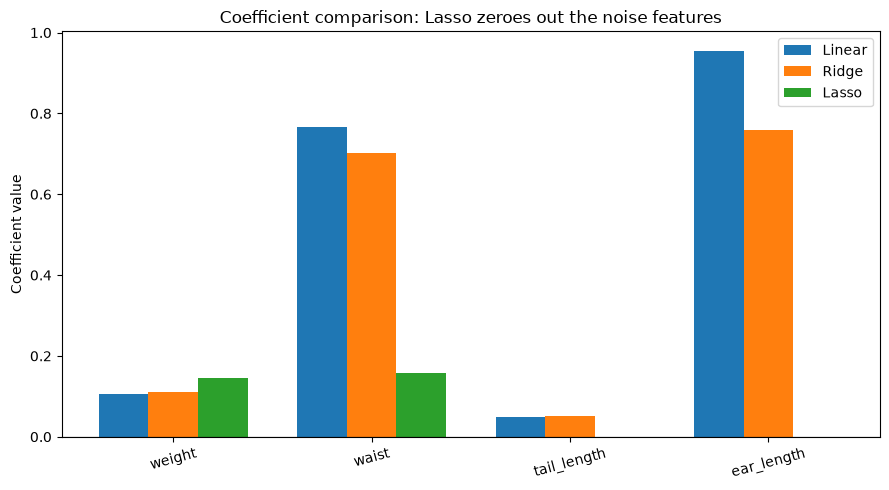

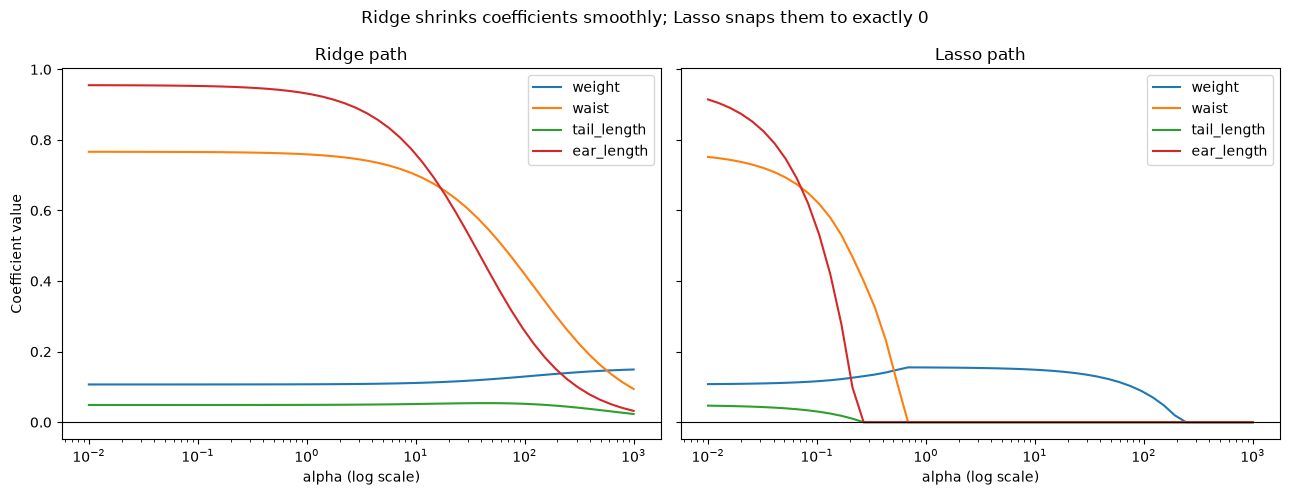

In [11]:
# ====================================
# 1. Coefficient comparison bar chart
# ====================================
# Lasso should push the two noise features (tail_length, ear_length) to ~0.

features = X.columns
x = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, linear.coef_, width, label="Linear")
ax.bar(x,         ridge.coef_,  width, label="Ridge")
ax.bar(x + width, lasso.coef_,  width, label="Lasso")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=15)
ax.set_ylabel("Coefficient value")
ax.set_title("Coefficient comparison: Lasso zeroes out the noise features")
ax.legend()
plt.tight_layout()
plt.show()


# ====================================
# 2. Regularization paths
# ====================================
# How each coefficient shrinks as the regularization strength (alpha) grows.

alphas = np.logspace(-2, 3, 50)

ridge_paths = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in alphas])
lasso_paths = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for i, feat in enumerate(features):
    axes[0].plot(alphas, ridge_paths[:, i], label=feat)
    axes[1].plot(alphas, lasso_paths[:, i], label=feat)

for ax, title in zip(axes, ["Ridge path", "Lasso path"]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("alpha (log scale)")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("Coefficient value")
fig.suptitle("Ridge shrinks coefficients smoothly; Lasso snaps them to exactly 0")
plt.tight_layout()
plt.show()